# Uji Sensitivitas Skor Peluang

Skor peluang di dashboard adalah rumus buatan sendiri:

```
skor peluang = nilai penjualan − jumlah pesaing + porsi pesaing lemah
```

Rumus ini tidak punya kunci jawaban. Tidak ada data "segmen ini terbukti menguntungkan" yang bisa dipakai untuk menguji ketepatannya, jadi skor ini tidak bisa divalidasi seperti model di notebook 03.

Yang bisa diuji adalah pertanyaan yang lebih sederhana: **apakah peringkatnya bertahan ketika hal-hal yang seharusnya tidak penting diubah?** Kalau peringkat teratas berganti hanya karena ambang digeser sedikit, peringkat itu tidak layak dijadikan dasar keputusan.

Ada dua sumber ketidakpastian yang diuji terpisah, karena artinya berbeda:

| Sumber | Pertanyaan | Cara uji | Bagian |
|---|---|---|---|
| Pilihan desain | Apakah hasilnya bergantung pada angka yang saya pilih sendiri? | Ubah ambang, bobot, transformasi, pemangkasan satu per satu | 1-2 |
| Kebetulan sampel | Apakah hasilnya bergantung pada produk mana yang kebetulan ter-scrape? | Bootstrap: ambil ulang sampel produk 300 kali | 3-4 |

Semua perhitungan memakai fungsi yang sama persis dengan dashboard (`src/opportunity.py`), hanya dengan satu asumsi yang diganti setiap kalinya.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src import clean_listings, opportunity, sensitivity
from src import plot_style as ps

ps.terapkan()
pd.set_option("display.max_colwidth", 60)

listings = clean_listings.bersihkan()
dasar = sensitivity.skor(listings)

dasar.head(10)[["peringkat", "skor_peluang", "jumlah_produk", "porsi_pesaing_lemah",
                "skor_permintaan", "skor_kompetisi", "skor_pesaing_lemah"]].style.format({
    "skor_peluang": "{:.2f}", "porsi_pesaing_lemah": "{:.0%}", "skor_permintaan": "{:+.2f}",
    "skor_kompetisi": "{:+.2f}", "skor_pesaing_lemah": "{:+.2f}",
})

[listings] 29,484 baris bersih (35 dibuang karena harga tidak valid)
[listings] 151 produk dipangkas nilainya; total nilai pasar turun 72%
[listings] sebaran kategori:
kategori
lainnya              7312
fashion              6534
rumah tangga         4592
elektronik           3424
kecantikan           2581
makanan & minuman    1533
handphone             916
buku & alat tulis     587
olahraga              489
pertukangan           440
ibu & bayi            408
otomotif              390
hewan peliharaan      278


Ini sepuluh segmen teratas versi dasar, sama dengan yang ada di notebook 01 bagian 6. Tiga kolom terakhir adalah komponen skornya dalam z-score. Ingat bahwa kompetisi *dikurangkan*, jadi nilai negatif di kolom itu justru menaikkan skor.

## 1. Pilihan desain

Tiga belas variasi, masing-masing mengubah **satu** hal dari versi dasar:

- **Ambang pesaing lemah** 4,5 / 4,6 / 4,8 / 4,9 (dasar: 4,7)
- **Bobot tiap komponen** dikali 0,5 atau 2 (dasar: semua 1)
- **Tanpa transformasi log** pada nilai penjualan dan jumlah pesaing
- **Persentil pemangkasan** P99 / P99,9 (dasar: P99,5)

Setiap nilai alternatif adalah pilihan yang sama-sama bisa dibela, bukan nilai ekstrem yang sengaja dicari untuk merusak hasil.

Dua ukuran yang dipakai:

- **Korelasi peringkat (Spearman)**: seberapa mirip urutan ke-48 segmen dengan versi dasar. Nilai 1 berarti urutannya sama persis.
- **Sama di top 5**: berapa dari lima segmen teratas versi dasar yang tetap berada di lima teratas.

In [2]:
hasil_desain, peringkat_desain = sensitivity.uji_desain(listings)
hasil_desain.style.format({"korelasi_peringkat": "{:.2f}"}).hide(axis="index")

variasi,korelasi_peringkat,sama_di_top5,peringkat_1
"Ambang 4,5",0.80,3,otomotif — Menengah
"Ambang 4,6",0.94,3,otomotif — Menengah
"Ambang 4,8",0.92,3,otomotif — Menengah
"Ambang 4,9",0.80,1,otomotif — Menengah
"Bobot permintaan ×0,5",0.82,3,otomotif — Menengah
Bobot permintaan ×2,0.68,2,otomotif — Menengah
"Bobot kompetisi ×0,5",0.87,2,otomotif — Menengah
Bobot kompetisi ×2,0.55,3,otomotif — Menengah
"Bobot pesaing lemah ×0,5",0.87,4,otomotif — Menengah
Bobot pesaing lemah ×2,0.95,3,otomotif — Menengah


Tiga hal terbaca dari tabel ini:

- **Persentil pemangkasan hampir tidak berpengaruh** (korelasi 0,99 ke atas). Keputusan memangkas di P99,5 aman: memangkas sedikit lebih banyak atau lebih sedikit tidak mengubah kesimpulan.
- **Bobot adalah asumsi paling sensitif.** Menggandakan bobot kompetisi atau permintaan menurunkan korelasi paling jauh. Ini wajar, karena bobot menentukan apa arti "peluang" itu sendiri.
- **Ambang 4,9 menggeser banyak.** Kuartil bawah rating listing adalah 4,8, jadi di ambang 4,9 setidaknya seperempat produk tergolong "lemah". Komponen itu kehilangan daya bedanya.

Tapi ada satu hal yang tidak berubah sama sekali: **peringkat 1 selalu otomotif Menengah**, di ketiga belas variasi.

Grafik berikut memperlihatkan hal yang sama per segmen. Garis abu-abu adalah rentang peringkat terendah hingga tertinggi di seluruh variasi, titik oranye adalah peringkat versi dasar.

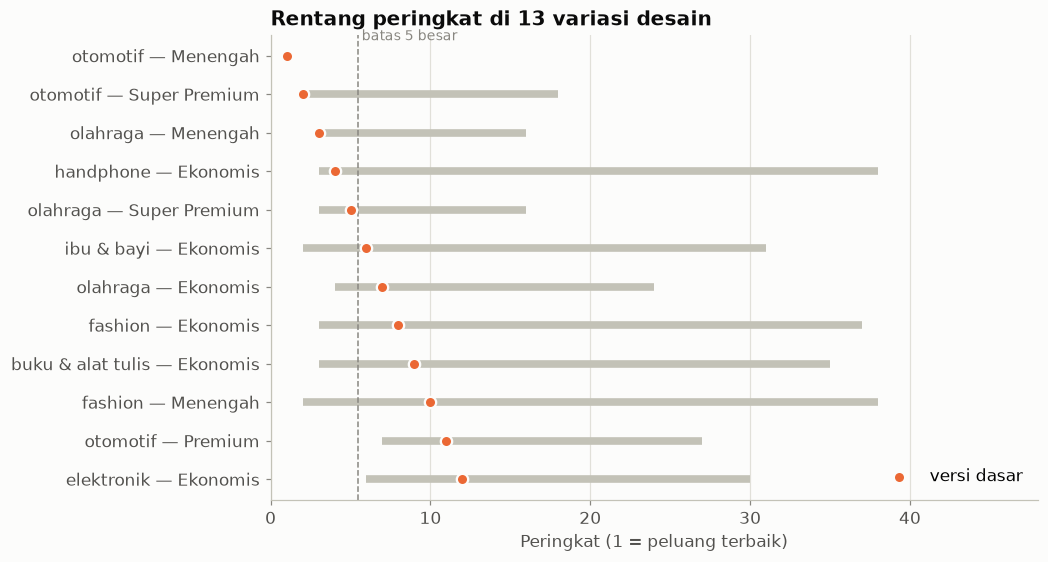

In [3]:
def label(indeks):
    return [f"{k} — {s}" for k, s in indeks]


def gambar_rentang(ax, bawah, atas, titik, judul, xlabel, titik_kedua=None):
    y = np.arange(len(titik))[::-1]
    ax.hlines(y, bawah, atas, color=ps.AXIS, linewidth=5, zorder=1)
    if titik_kedua is not None:
        ax.scatter(titik_kedua, y, s=45, color=ps.BIRU, zorder=2, label="median bootstrap",
                   edgecolor=ps.SURFACE, linewidth=1.5)
    ax.scatter(titik, y, s=55, color=ps.ORANYE, zorder=3, label="versi dasar",
               edgecolor=ps.SURFACE, linewidth=1.5)
    ax.axvline(5.5, color=ps.MUTED, linestyle="--", linewidth=1)
    ax.text(5.7, len(titik) - 0.6, "batas 5 besar", color=ps.MUTED, fontsize=9)
    ax.set_yticks(y, label(titik.index))
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, 48)
    ax.set_title(judul)
    ax.legend(loc="lower right", frameon=False)


atas12 = peringkat_desain.sort_values("Dasar").head(12)
fig, ax = plt.subplots(figsize=(9, 5.5))
gambar_rentang(ax, atas12.min(axis=1), atas12.max(axis=1), atas12["Dasar"],
               "Rentang peringkat di 13 variasi desain", "Peringkat (1 = peluang terbaik)")
plt.show()

Dua segmen teratas tetap di papan atas hampir di semua variasi. Di bawahnya, rentangnya melebar tajam: segmen di peringkat 4 sampai 10 bisa jatuh ke peringkat 30-an hanya karena satu asumsi diubah.

## 2. Komponen mana yang menentukan?

Uji kedua lebih kasar: buang satu komponen sepenuhnya, lalu lihat siapa yang naik ke papan atas. Ini menunjukkan komponen mana yang sebenarnya menggerakkan peringkat.

In [4]:
sensitivity.uji_ablasi(listings).style.hide(axis="index")

komponen dibuang,sama_di_top5,top5
Tanpa permintaan,3,"['otomotif — Menengah', 'otomotif — Super Premium', 'buku & alat tulis — Ekonomis', 'ibu & bayi — Ekonomis', 'olahraga — Menengah']"
Tanpa kompetisi,1,"['fashion — Ekonomis', 'fashion — Menengah', 'otomotif — Menengah', 'rumah tangga — Ekonomis', 'elektronik — Ekonomis']"
Tanpa pesaing lemah,1,"['handphone — Super Premium', 'olahraga — Super Premium', 'kecantikan — Premium', 'handphone — Menengah', 'kecantikan — Super Premium']"


Membuang **kompetisi** atau **pesaing lemah** mengubah papan atas hampir seluruhnya. Membuang **permintaan** mengubah paling sedikit.

Tabel di awal notebook menjelaskan kenapa: **tujuh dari sepuluh segmen teratas punya nilai penjualan di bawah rata-rata**, termasuk peringkat 1 (z-score −0,81). Segmen-segmen itu naik karena pesaingnya sedikit dan banyak yang mengecewakan, bukan karena uang yang berputar besar.

Bagi calon penjual, ini penting diketahui: "peluang terbaik" versi rumus ini adalah **pasar yang sepi dan kurang terlayani**, belum tentu pasar yang besar.

Ini temuan yang perlu diungkapkan, bukan diperbaiki diam-diam. Godaannya adalah mengubah bobot sampai papan atas "terlihat masuk akal", tapi itu sama dengan memilih jawaban dulu lalu mencari rumus yang menghasilkannya. Kalau nilai penjualan memang harus lebih menentukan, itu keputusan bisnis yang diambil sebelum melihat hasil, sama seperti pemilihan metrik di notebook 03.

## 3. Kebetulan sampel: bootstrap

Uji di bagian 1-2 menjawab apakah hasilnya bergantung pada *pilihan saya*. Bagian ini menjawab apakah hasilnya bergantung pada *data yang kebetulan terkumpul*.

Caranya: ambil 29 ribu produk secara acak **dengan pengembalian** dari data yang sama. Sebagian produk terambil dua kali, sebagian tidak terambil sama sekali. Lalu seluruh proses diulang dari awal, termasuk batas segmen harga, karena batas kuartil itu sendiri bergantung pada sampel. Proses ini diulang 300 kali.

Kalau sebuah segmen benar-benar menonjol, ia akan tetap di atas pada sebagian besar sampel ulang. Kalau posisinya hanya kebetulan, ia akan naik-turun.

In [5]:
peringkat_boot = sensitivity.bootstrap(listings)
stabilitas = sensitivity.ringkas_bootstrap(listings, peringkat_boot)

tampil = stabilitas.head(12).set_index(["kategori", "segmen_harga"])
tampil.style.format({
    "peringkat_median": "{:.0f}", "peringkat_p5": "{:.0f}", "peringkat_p95": "{:.0f}",
    "porsi_top1": "{:.0%}", "porsi_top5": "{:.0%}", "porsi_top10": "{:.0%}",
})

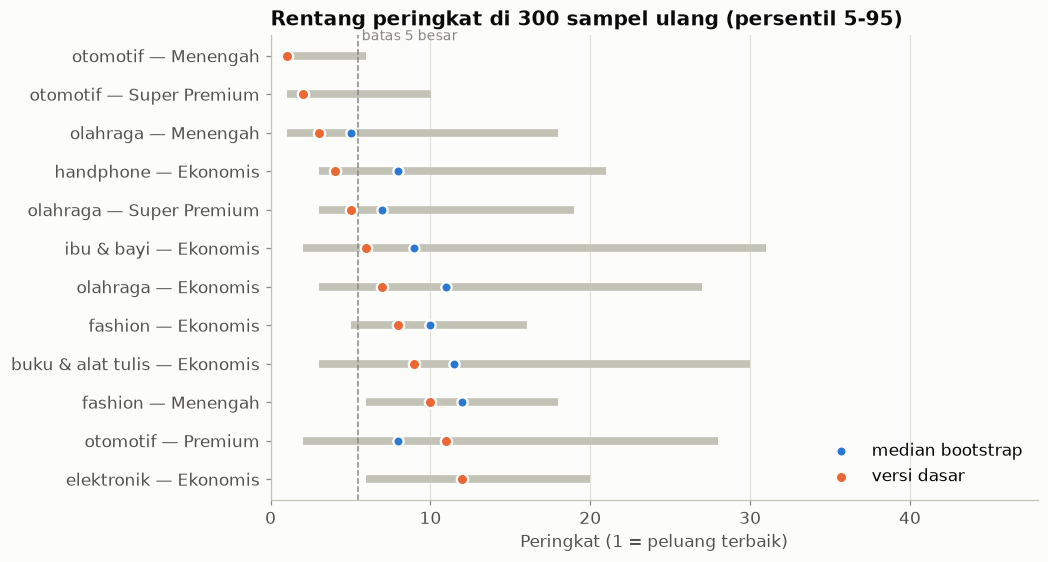

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
gambar_rentang(ax, tampil["peringkat_p5"], tampil["peringkat_p95"], tampil["peringkat"],
               "Rentang peringkat di 300 sampel ulang (persentil 5-95)",
               "Peringkat (1 = peluang terbaik)", titik_kedua=tampil["peringkat_median"])
plt.show()

Polanya sama dengan uji desain, dan kali ini dengan angka yang lebih mudah dibaca:

- **Dua segmen otomotif kokoh.** Otomotif Menengah bertahan di 5 besar pada 95% sampel ulang, otomotif Super Premium pada 87%.
- **Peringkat 3 ke bawah rapuh.** Olahraga Menengah (peringkat 3) masih bertahan di sekitar separuh sampel. Segmen di peringkat 4-10 umumnya hanya bertahan di 5 besar pada kurang dari 40% sampel ulang.
- **Urutan di tengah praktis tidak bisa dibedakan.** Otomotif Premium, yang di versi dasar ada di peringkat 11, justru lebih sering masuk 5 besar daripada handphone Ekonomis di peringkat 4.

Konsekuensinya untuk dashboard: tabel "lima segmen dengan peluang terbaik" hanya layak dibaca sebagai peringkat untuk dua atau tiga baris pertama. Sisanya adalah kandidat yang setara. Karena itu dashboard sekarang menampilkan kolom **Bertahan di 5 besar**, diambil dari bootstrap ini.

## 4. Apakah peringkat 1 berdiri di atas segelintir produk?

Otomotif Menengah menang terutama karena komponen pesaing lemahnya sangat tinggi (z-score di atas 3). Porsi itu hanya dihitung dari produk yang **punya rating**. Kalau hanya sedikit produk yang dirating, "20% pesaing lemah" bisa berarti dua atau tiga produk saja.

In [7]:
segmen = opportunity.beri_segmen_harga(listings[listings["kategori"] != "lainnya"])
hitungan = segmen.groupby(["kategori", "segmen_harga"]).agg(
    produk=("rating", "size"),
    dirating=("rating", "count"),
    lemah=("rating", lambda r: (r.dropna() < opportunity.AMBANG_PESAING_LEMAH).sum()),
)
print(f"Median produk berating per segmen, semua 48 segmen: {hitungan['dirating'].median():.0f}")
hitungan.loc[dasar.head(5).index]

Median produk berating per segmen, semua 48 segmen: 174


produk  dirating  lemah
kategori  segmen_harga                          
otomotif  Menengah           97        95     19
          Super Premium      97        83     11
olahraga  Menengah          122       113     11
handphone Ekonomis          229       208     25
olahraga  Super Premium     122       109      7

Kekhawatiran itu tidak terbukti. Otomotif Menengah punya 95 produk berating, 19 di antaranya di bawah 4,7. Jumlah itu di bawah median segmen lain, tapi bukan segelintir, dan bootstrap di bagian 3 sudah menunjukkan posisinya bertahan meski produknya diambil ulang.

## 5. Yang tidak bisa dijawab oleh uji ini

Bootstrap mengukur **variasi** sampel, bukan **bias**-nya. Setiap sampel ulang diambil dari data yang sama. Kalau otomotif memang jarang ikut ter-scrape, sehingga tampak sepi pesaing padahal pasarnya ramai, maka ketiga ratus sampel ulang mewarisi kekurangan yang sama, dan otomotif akan tetap "kokoh" di peringkat 1.

Jadi hasil notebook ini perlu dibaca dengan tepat:

- **Kokoh** berarti peringkatnya tidak bergantung pada pilihan desain atau kebetulan sampel.
- **Kokoh tidak sama dengan benar.** Untuk memastikan otomotif memang sepi pesaing, dibutuhkan data dari luar, misalnya jumlah listing per kategori langsung dari Tokopedia. Keterbatasan ini sudah dicatat di README dan tidak bisa diselesaikan dengan data yang ada.

## Ringkasan

| Uji | Temuan | Implikasi |
|---|---|---|
| Persentil pemangkasan | Hampir tidak berpengaruh | Pilihan P99,5 aman |
| Ambang dan bobot | Bobot paling sensitif, lalu ambang 4,9 | Bobot adalah keputusan bisnis, bukan detail teknis |
| Ablasi | Pesaing sedikit dan pesaing lemah yang menentukan papan atas; 7 dari 10 segmen teratas bernilai penjualan di bawah rata-rata | Skor menunjuk pasar sepi yang kurang terlayani, belum tentu pasar besar; diungkapkan, bukan diatur ulang |
| Bootstrap | Dua segmen otomotif bertahan di 5 besar pada ≥87% sampel ulang; peringkat 4-10 umumnya di bawah 40% | Dashboard menampilkan kolom stabilitas |
| Jumlah produk berating | Peringkat 1 bertumpu pada 95 produk berating | Bukan artefak dari sampel yang sangat kecil |
| Bias sampel | Tidak bisa diuji dengan data ini | Kokoh bukan berarti benar; butuh data luar |